### 📊 Dimensionality Reduction:
Communicatiestijl per bewoner (gedragsclusters)

✅ Kernset (8 features) — ideaal startpunt

Dit dekt bijna alle stijlen die jij verwacht.

avg_message_length

message_length_std

emoji_ratio

link_ratio

topk_ratio

msg_count_norm

avg_hour

day_of_week_std (of entropy)

➡️ Dit is compact, interpreteerbaar en cluster-vriendelijk.

Alternatieve lichte variant (6 features)

Als je dataset klein is:

avg_message_length

emoji_ratio

link_ratio

topk_ratio

msg_count_norm

day_of_week_std

Features die je bewust NIET gebruikt

❌ Entrance_nr, Floor_nr
→ andere onderzoeksvraag

❌ Volledige tekst / embeddings
→ clusters worden topics, geen stijl

❌ Ruwe day_of_week one-hot
→ te veel dimensies

❌ timestamp_category
→ te grof, weinig stijl-informatie

Ik wil dimensionality reduction analyse doen voor Communicatiestijl per bewoner (gedragsclusters) van mijn whatapp chatgroep van mijn flatgebouw, en proberen een cluster te ontdekken.

chatfeatures (per author geaggregeerd):
•	Gemiddelde message_length
•	% berichten met has_emoji
•	% berichten met has_link
•	% is_topk
•	Aantal berichten (of genormaliseerd)
•	Gemiddelde hour
•	% berichten in avond / weekend

✅ Kernset (8 features) — ideaal startpunt

Dit dekt bijna alle stijlen die jij verwacht.

avg_message_length

message_length_std

emoji_ratio

link_ratio

topk_ratio

msg_count_norm

avg_hour

day_of_week_std (of entropy)



Let op ik heb een kleine dataset (4500 whatsapp berichten)

Alternatieve lichte variant (6 features)

Als je dataset klein is:

avg_message_length

emoji_ratio

link_ratio

topk_ratio

msg_count_norm

day_of_week_std


De dataset dataframe van mijn whatapp groep levert deze kolommen:
['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length']

Ik heb verder meta data beschikbaar van de bewoners (auteurs) van de whatsapp groep in json formaat, hier enkele voorbeelden:
"bouncy-worm": {
    "Name": "F",
    "Gender": "Female",
    "Entrance_nr": 2,
    "Unit_nr": 238,
    "Floor_nr": 5,
    "Nr_rooms": 5,
    "Board_function": "not_applicable"
  },
  "cackling-eland": {
    "Name": "MS",
    "Gender": "Female",
    "Entrance_nr": 2,
    "Unit_nr": 241,
    "Floor_nr": 6,
    "Nr_rooms": 5,
    "Board_function": "Bestuurslid_1"
  },
  "captivating-dove": {
    "Name": "B",
    "Gender": "Male",
    "Entrance_nr": 1,
    "Unit_nr": 206,
    "Floor_nr": 3,
    "Nr_rooms": 5,
    "Board_function": "not_applicable"
  },

Help met dit opzetten stap voor stap met duidelijk uitleg voor in een python notebook

### 🔹 Stap 1 – Libraries importeren

pandas / numpy → data

StandardScaler → verplicht voor PCA

PCA / TSNE → dimensionality reduction

matplotlib / seaborn → visualisatie

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path
import tomllib
from loguru import logger
import csv
import regex as re

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances
from sklearn.cluster import DBSCAN


from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --- Configuration ---
sns.set_theme(style="whitegrid", palette="muted")

### 🔹 Stap 2 – Data inladen

In [50]:
# --- Load configuration and data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning(
        "Datafile does not exist. Run src/preprocess.py first and check the timestamp!"
    )

df = pd.read_parquet(datafile)
df.columns
# df.head()

Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length'],
      dtype='object')

In [51]:
# --- Load metadata ---
# meta data (test): nested_users5.json
# meta data (prod): resident_metadata.json

with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

meta_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={"index": "author"})
)

# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

# author_info_df.columns
# author_info_df.head()

### 🔹 Stap 3 – Chatfeatures per auteur berekenen

In [52]:
df["hour_int"] = df["hour"].apply(lambda t: t.hour)
df["is_evening"] = df["hour_int"].between(18, 23)

In [53]:
author_features = (
    df
    .groupby("author")
    .agg(
        msg_count=("message", "count"),
        avg_message_length=("message_length", "mean"),
        message_length_std=("message_length", "std"),
        emoji_ratio=("has_emoji", "mean"),
        link_ratio=("has_link", "mean"),
        topk_ratio=("is_topk", "mean"),
        avg_hour=("hour_int", "mean"),
        day_of_week_std=("day_of_week", "std"),
    )
    .reset_index()
)


In [54]:
author_features["msg_count_norm"] = (
    author_features["msg_count"] / author_features["msg_count"].sum()
)


In [55]:
author_features.columns

Index(['author', 'msg_count', 'avg_message_length', 'message_length_std',
       'emoji_ratio', 'link_ratio', 'topk_ratio', 'avg_hour',
       'day_of_week_std', 'msg_count_norm'],
      dtype='object')

In [56]:
author_features[feature_cols].isna().sum()


avg_message_length    0
message_length_std    4
emoji_ratio           0
link_ratio            0
topk_ratio            0
msg_count_norm        0
avg_hour              0
day_of_week_std       4
dtype: int64

In [57]:
std_cols = ["message_length_std", "day_of_week_std"]

author_features[std_cols] = author_features[std_cols].fillna(0)


In [58]:
author_features["msg_count_norm"] = (
    author_features["msg_count"] / author_features["msg_count"].sum()
)


In [59]:
author_features.drop(columns="msg_count", inplace=True)


In [60]:
feature_cols = [
    "avg_message_length",
    "message_length_std",
    "emoji_ratio",
    "link_ratio",
    "topk_ratio",
    "msg_count_norm",
    "avg_hour",
    "day_of_week_std",
]


In [61]:
# pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler()),
#     ("pca", PCA(n_components=2))
# ])

# X_pca = pipeline.fit_transform(author_features)

In [62]:
X = author_features[feature_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [63]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

author_features["PC1"] = X_pca[:, 0]
author_features["PC2"] = X_pca[:, 1]


In [64]:
# 9
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

loadings


,PC1,PC2
avg_message_length,0.485000,-0.425777
message_length_std,0.543124,-0.270076
emoji_ratio,0.166646,0.347379
link_ratio,0.062238,-0.305306
topk_ratio,0.413518,0.495521
msg_count_norm,0.417152,0.460964
avg_hour,-0.005722,-0.003167
day_of_week_std,0.305125,-0.271753


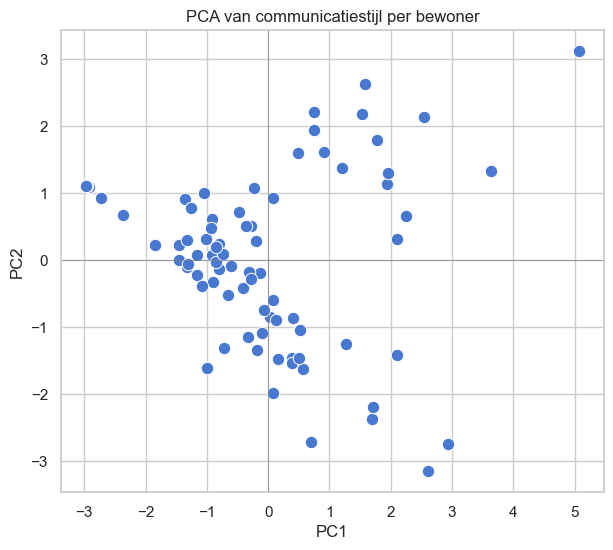

In [65]:
# 10
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=author_features,
    x="PC1",
    y="PC2",
    s=80
)

plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.title("PCA van communicatiestijl per bewoner")
plt.show()


In [66]:
#11
tsne = TSNE(
    n_components=2,
    perplexity=5,      # klein, want weinig auteurs
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

author_features["TSNE1"] = X_tsne[:, 0]
author_features["TSNE2"] = X_tsne[:, 1]


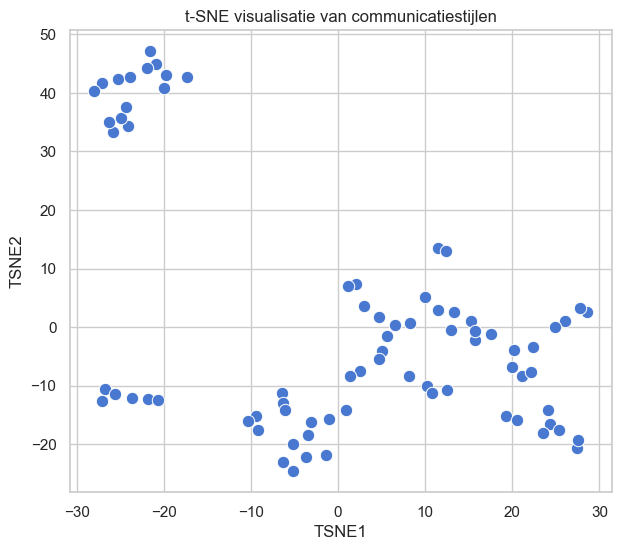

In [67]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=author_features,
    x="TSNE1",
    y="TSNE2",
    s=80
)

plt.title("t-SNE visualisatie van communicatiestijlen")
plt.show()


In [68]:
# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

author_features = author_features.merge(
    meta_df[["author", "Board_function"]],
    on="author",
    how="left"
)


✅ Wat je nu hebt

✔️ Correcte featureselectie
✔️ PCA (interpreteerbaar)
✔️ t-SNE (intuïtief)
✔️ Clusters als stijlen, niet personen
✔️ Geschikt voor kleine datasets

In [69]:
# --- Clusteranalyse op t-SNE ---
dbscan = DBSCAN(
    eps=4,          # kan je tunen: 3–6 is meestal goed
    min_samples=3   # minimaal aantal auteurs per cluster
)

author_features["cluster"] = dbscan.fit_predict(
    author_features[["TSNE1", "TSNE2"]]
)

author_features["cluster"].value_counts()


cluster
 3    24
 0    15
 4    10
 2     8
 5     6
 7     5
 1     4
 6     4
-1     2
Name: count, dtype: int64

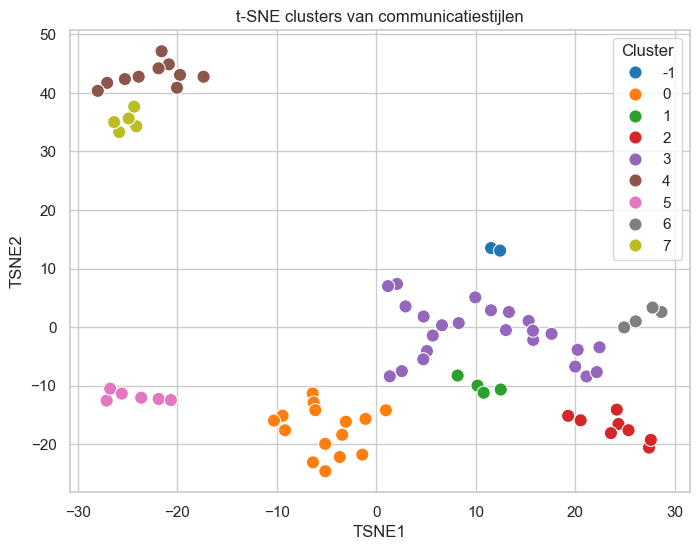

In [70]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=author_features,
    x="TSNE1",
    y="TSNE2",
    hue="cluster",
    palette="tab10",
    s=90
)

plt.title("t-SNE clusters van communicatiestijlen")
plt.legend(title="Cluster")
plt.show()


In [71]:
feature_cols = [
    "avg_message_length",
    "message_length_std",
    "emoji_ratio",
    "link_ratio",
    "topk_ratio",
    "msg_count_norm",
    "avg_hour",
    "day_of_week_std",
]

cluster_summary = (
    author_features
    .groupby("cluster")[feature_cols]
    .mean()
    .round(3)
)

cluster_summary


,avg_message_length,message_length_std,emoji_ratio,link_ratio,topk_ratio,msg_count_norm,avg_hour,day_of_week_std
cluster,,,,,,,,
-1,90.000,30.406,0.000,0.000,0.0,0.000,14.750,4.243
0,145.251,159.511,0.111,0.010,0.0,0.003,14.037,1.973
1,76.793,103.625,0.130,0.006,0.0,0.005,16.355,1.544
2,70.204,69.917,0.453,0.003,0.0,0.006,14.533,1.629
3,61.509,49.984,0.062,0.001,0.0,0.007,15.786,1.643
4,104.334,151.895,0.264,0.016,1.0,0.053,14.857,1.824
5,89.006,112.020,0.018,0.172,0.0,0.004,14.787,1.726
6,52.708,31.490,0.000,0.000,0.0,0.001,9.792,0.545
7,69.955,70.353,0.122,0.002,1.0,0.033,14.535,1.860


In [72]:
cluster_summary_z = (
    (cluster_summary - cluster_summary.mean())
    / cluster_summary.std()
)

cluster_summary_z.round(2)


,avg_message_length,message_length_std,emoji_ratio,link_ratio,topk_ratio,msg_count_norm,avg_hour,day_of_week_std
cluster,,,,,,,,
-1,0.20,-1.17,-0.87,-0.42,-0.50,-0.69,0.20,2.41
0,2.19,1.51,-0.12,-0.24,-0.50,-0.52,-0.19,0.09
1,-0.28,0.35,0.01,-0.31,-0.50,-0.41,1.06,-0.35
2,-0.51,-0.35,2.20,-0.36,-0.50,-0.35,0.08,-0.26
3,-0.83,-0.76,-0.45,-0.40,-0.50,-0.30,0.76,-0.25
4,0.72,1.35,0.92,-0.13,1.76,2.23,0.26,-0.06
5,0.17,0.53,-0.75,2.65,-0.50,-0.46,0.22,-0.17
6,-1.14,-1.14,-0.87,-0.42,-0.50,-0.63,-2.47,-1.37
7,-0.52,-0.34,-0.05,-0.38,1.76,1.13,0.08,-0.03


In [73]:
cluster_labels = {
    0: "Expressieve sociale chatters",
    1: "Stille functionele gebruikers",
    2: "Informatieve schrijvers",
    3: "Actieve snelle reageerders",
    -1: "Outliers / atypisch gedrag"
}

author_features["cluster_label"] = author_features["cluster"].map(cluster_labels)


In [74]:
author_features[[
    "author",
    "cluster",
    "cluster_label",
    "msg_count_norm",
    "avg_message_length",
    "emoji_ratio"
]].sort_values("cluster")


,author,cluster,cluster_label,msg_count_norm,avg_message_length,emoji_ratio
25,flecked-pheasant,-1,Outliers / atypisch gedrag,0.000438,87.000000,0.000000
43,merry-salamander,-1,Outliers / atypisch gedrag,0.000438,93.000000,0.000000
13,cordial-eel,0,Expressieve sociale chatters,0.004381,97.350000,0.250000
0,bejeweled-beluga,0,Expressieve sociale chatters,0.000876,243.750000,0.000000
15,dazzling-curlew,0,Expressieve sociale chatters,0.002629,105.833333,0.166667
...,...,...,...,...,...,...
61,silky-lapwing,7,NaN,0.040526,74.340541,0.032432
26,flexible-platypus,7,NaN,0.040745,55.193548,0.166667
40,limber-ostrich,7,NaN,0.035049,58.643750,0.137500
68,sudsy-eland,7,NaN,0.026287,60.441667,0.058333


In [75]:
cluster_summary.assign(
    label=cluster_summary.index.map(cluster_labels)
)


,avg_message_length,message_length_std,emoji_ratio,link_ratio,topk_ratio,msg_count_norm,avg_hour,day_of_week_std,label
cluster,,,,,,,,,
-1,90.000,30.406,0.000,0.000,0.0,0.000,14.750,4.243,Outliers / atypisch gedrag
0,145.251,159.511,0.111,0.010,0.0,0.003,14.037,1.973,Expressieve sociale chatters
1,76.793,103.625,0.130,0.006,0.0,0.005,16.355,1.544,Stille functionele gebruikers
2,70.204,69.917,0.453,0.003,0.0,0.006,14.533,1.629,Informatieve schrijvers
3,61.509,49.984,0.062,0.001,0.0,0.007,15.786,1.643,Actieve snelle reageerders
4,104.334,151.895,0.264,0.016,1.0,0.053,14.857,1.824,NaN
5,89.006,112.020,0.018,0.172,0.0,0.004,14.787,1.726,NaN
6,52.708,31.490,0.000,0.000,0.0,0.001,9.792,0.545,NaN
7,69.955,70.353,0.122,0.002,1.0,0.033,14.535,1.860,NaN
